In [173]:
import os
import shutil
from datetime import datetime
import json

import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

In [174]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

In [175]:
def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

In [176]:
# new_data = {}
# new_data['data'] = data

# save_nested_dict_to_hdf5(data_filename, new_data)

In [177]:
# new_data = load_nested_dict_from_hdf5(data_filename)

# # - - total_bond_order_error
# # - - total_bond_order_error_corrected
# # - - total_bond_order_value
# # - - total_bond_order_value_corrected


# new_data['data']['coupling_point_2']['highest']['bond_order_total'] = new_data['data']['coupling_point_2']['highest']['total_bond_order_value']
# new_data['data']['coupling_point_2']['highest']['bond_order_total_error'] = new_data['data']['coupling_point_2']['highest']['total_bond_order_error']
# new_data['data']['coupling_point_2']['highest']['bond_order_total_corrected'] = new_data['data']['coupling_point_2']['highest']['total_bond_order_value_corrected']
# new_data['data']['coupling_point_2']['highest']['bond_order_total_error_corrected'] = new_data['data']['coupling_point_2']['highest']['total_bond_order_error_corrected']

# del new_data['data']['coupling_point_2']['highest']['total_bond_order_error']
# del new_data['data']['coupling_point_2']['highest']['total_bond_order_error_corrected']
# del new_data['data']['coupling_point_2']['highest']['total_bond_order_value']
# del new_data['data']['coupling_point_2']['highest']['total_bond_order_value_corrected']

# backup_data(data_filename)
# save_nested_dict_to_hdf5(data_filename, new_data)

In [178]:
data_filename = 'bond_order_data.h5'

data = load_nested_dict_from_hdf5(data_filename)

In [179]:
print_tree(data['data'], max_level=3)

coupling_point_1
- highest
- - (1, 2)
- - (2, 3)
- - (3, 4)
- - (4, 5)
- - (5, 6)
- - (6, 7)
- - (7, 8)
- - bond_order_total
- - bond_order_total_corrected
- - bond_order_total_error
- - bond_order_total_error_corrected
- highest_postselection
- - (1, 2)
- - (2, 3)
- - (3, 4)
- - (4, 5)
- - (5, 6)
- - (6, 7)
- - (7, 8)
- - bond_order_total
- - bond_order_total_corrected
- - bond_order_total_error
- - bond_order_total_error_corrected
coupling_point_2
- highest
- - (1, 2)
- - (2, 3)
- - (3, 4)
- - (4, 5)
- - (5, 6)
- - (6, 7)
- - (7, 8)
- - bond_order_total
- - bond_order_total_corrected
- - bond_order_total_error
- - bond_order_total_error_corrected
- highest_postselection
- - (1, 2)
- - (2, 3)
- - (3, 4)
- - (4, 5)
- - (5, 6)
- - (6, 7)
- - (7, 8)
- - bond_order_total
- - bond_order_total_corrected
- - bond_order_total_error
- - bond_order_total_error_corrected
coupling_point_3
- highest
- - (1, 2)
- - (2, 3)
- - (3, 4)
- - (4, 5)
- - (5, 6)
- - (6, 7)
- - (7, 8)
- - bond_order_total
-

In [180]:
print_tree(data['simulation']['highest']['real']['coupling_point_1'], max_level=2)

(1, 2)
- population_difference
- beamsplitter_time
- bond_order_value
- bond_order_value_BS
(2, 3)
- population_difference
- beamsplitter_time
- bond_order_value
- bond_order_value_BS
(3, 4)
- population_difference
- beamsplitter_time
- bond_order_value
- bond_order_value_BS
(4, 5)
- population_difference
- beamsplitter_time
- bond_order_value
- bond_order_value_BS
(5, 6)
- population_difference
- beamsplitter_time
- bond_order_value
- bond_order_value_BS
(6, 7)
- population_difference
- beamsplitter_time
- bond_order_value
- bond_order_value_BS
(7, 8)
- population_difference
- beamsplitter_time
- bond_order_value
- bond_order_value_BS
bond_order_total
bond_order_total_BS


# 1. Plot Single Coupling Point

In [181]:
coupling_point = 'coupling_point_1'
# coupling_point = 'coupling_point_2'
# coupling_point = 'coupling_point_3'
# coupling_point = 'coupling_point_4'
# coupling_point = 'coupling_point_5_retake'
coupling_point = 'coupling_point_6_retake'

coupling_point_sim = coupling_point
# coupling_point_sim = 'coupling_point_6'

eigenstate = 'highest'
eigenstate = 'highest'
# eigenstate = 'lowest'

eigenstate_base = eigenstate.split('_')[0]

pairs = [(i,i+1) for i in range(1,8)]


### 1.1 Plot Bond Order vs Time

dict_keys(['population_difference', 'times', 'beamsplitter_time', 'bond_order_error', 'bond_order_error_corrected', 'bond_order_value', 'bond_order_value_corrected'])
0.02154918490402019


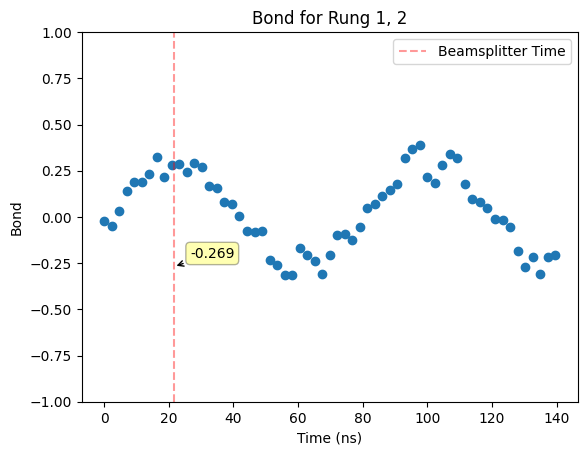

dict_keys(['population_difference', 'times', 'beamsplitter_time', 'bond_order_error', 'bond_order_error_corrected', 'bond_order_value', 'bond_order_value_corrected'])
0.017342151680961627


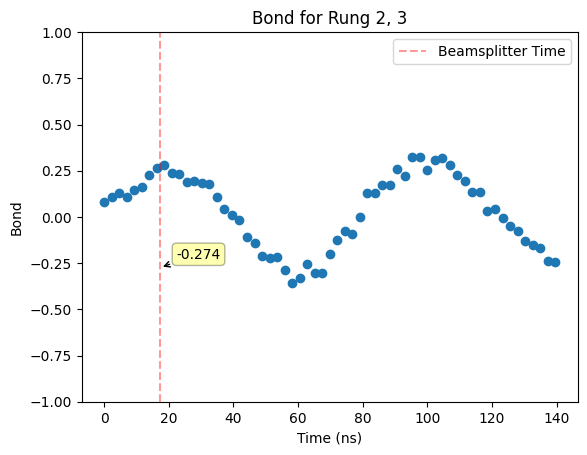

dict_keys(['population_difference', 'times', 'beamsplitter_time', 'bond_order_error', 'bond_order_error_corrected', 'bond_order_value', 'bond_order_value_corrected'])
0.022850432178790542


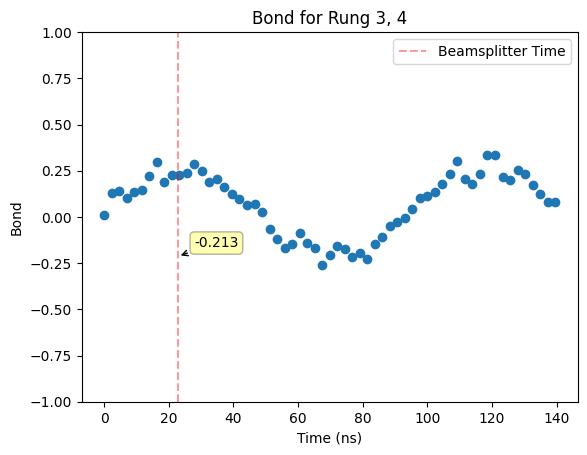

dict_keys(['population_difference', 'times', 'beamsplitter_time', 'bond_order_error', 'bond_order_error_corrected', 'bond_order_value', 'bond_order_value_corrected'])
0.01938865257578931


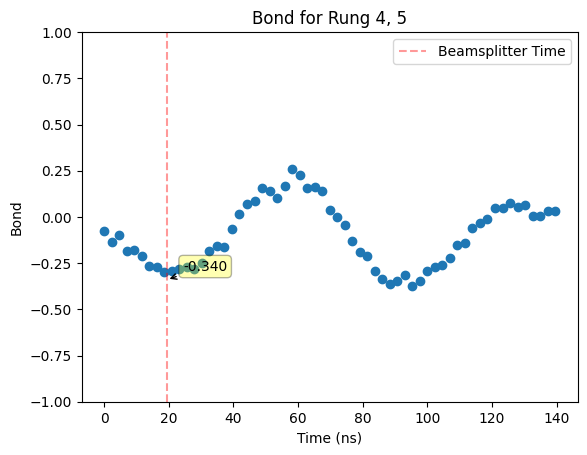

dict_keys(['population_difference', 'times', 'beamsplitter_time', 'bond_order_error', 'bond_order_error_corrected', 'bond_order_value', 'bond_order_value_corrected'])
0.018435011544142975


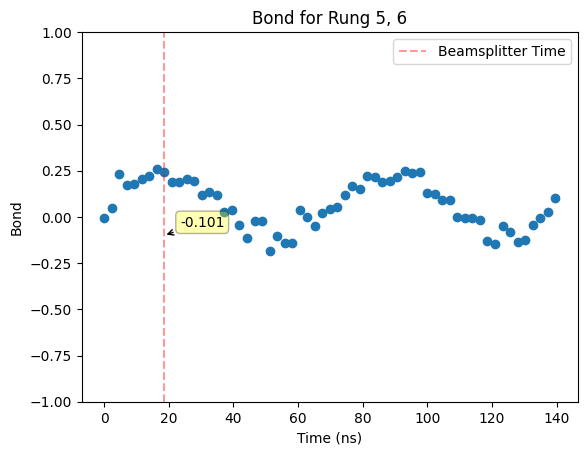

dict_keys(['population_difference', 'times', 'beamsplitter_time', 'bond_order_error', 'bond_order_error_corrected', 'bond_order_value', 'bond_order_value_corrected'])
0.024073157530262672


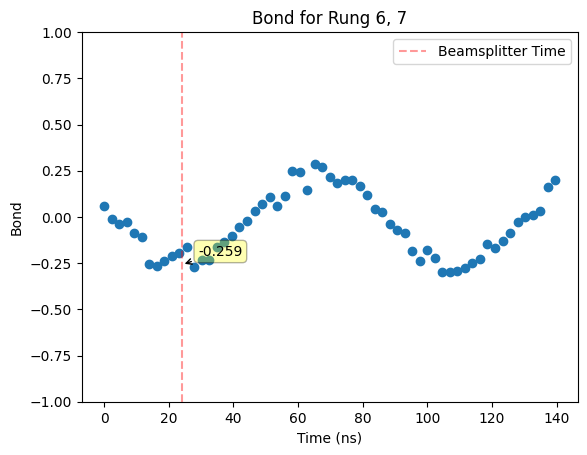

dict_keys(['population_difference', 'times', 'beamsplitter_time', 'bond_order_error', 'bond_order_error_corrected', 'bond_order_value', 'bond_order_value_corrected'])
0.01658210664927743


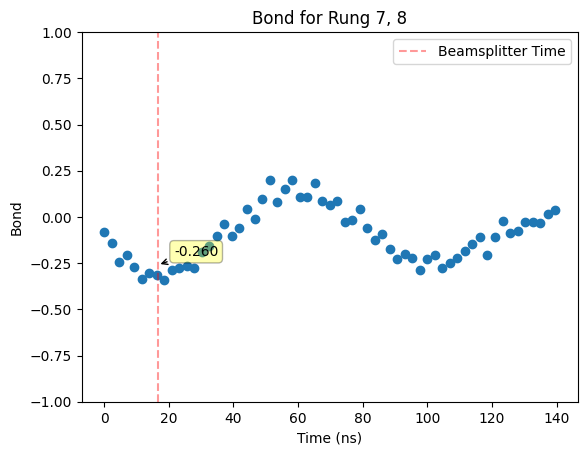

In [182]:
for pair in pairs:

    pair_data = data['data'][coupling_point][eigenstate][str(pair)]

    print(pair_data.keys())

    times = pair_data['times']
    beamsplitter_time = pair_data['beamsplitter_time']

    print(beamsplitter_time)

    population_difference = pair_data['population_difference']
    bond_order_value = pair_data['bond_order_value']

    plt.plot(times, population_difference, linestyle='', marker='o')

    plt.axvline(beamsplitter_time*1e3, color='r', alpha=0.4, linestyle='--', label='Beamsplitter Time')
   
    plt.xlabel('Time (ns)')
    plt.ylabel('Bond')
    plt.title(f'Bond for Rung {pair[0]}, {pair[1]}')
    plt.legend()

    plt.annotate(f'{bond_order_value:.3f}',
                 xy=(beamsplitter_time*1e3, bond_order_value),
                 xytext=(beamsplitter_time*1e3 + 5, bond_order_value + 0.05),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))

    plt.ylim(-1, 1)

    plt.show()


### 1.2 Plot Bond Order Value

C:\Users\mattm\AppData\Local\Temp\ipykernel_25004\3890032797.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


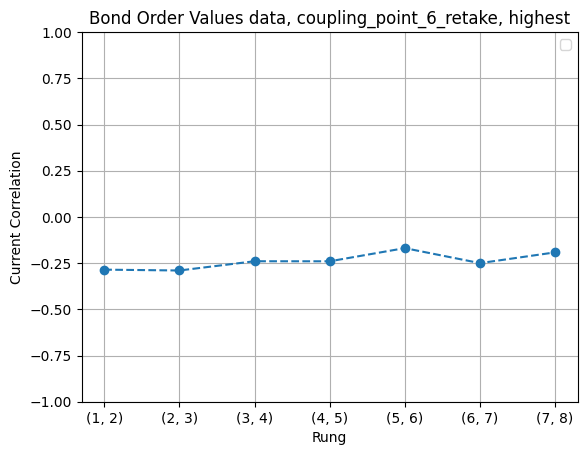

In [183]:
bond_order_values_data = [data['data'][coupling_point][eigenstate][str(pair)]['bond_order_value_corrected'] for pair in pairs]

# plot
plt.plot(range(len(pairs)), bond_order_values_data, marker='o', linestyle='--')

plt.xlabel('Rung')
plt.xticks(range(len(pairs)), [str(pair) for pair in pairs])


plt.ylabel('Current Correlation')

plt.legend()

plt.grid()

plt.title(f'Bond Order Values data, {coupling_point}, {eigenstate}')

plt.ylim(-1, 1)

plt.show()


# 2. Simulation

In [184]:
dephasing = 'real'

In [185]:
print_tree(data['simulation'], max_level=5)

highest
- 0.01
- - coupling_point_2
- - - (1, 2)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (2, 3)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (3, 4)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (4, 5)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (5, 6)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (6, 7)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (7, 8)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - bond_order_total
- - - bond_order_total_BS
- 0.1
- - coupling_point_2
- - - (1, 2)
- - - - population_di

### 2.2 Bond Order Value Simulation

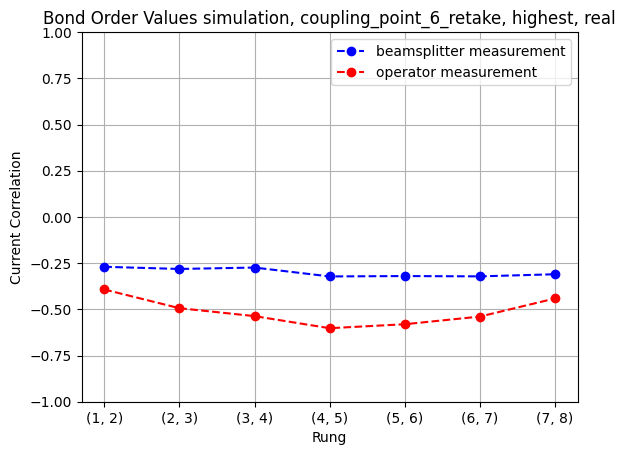

In [186]:
bond_order_values_BS = [data['simulation'][eigenstate_base][dephasing][coupling_point_sim][str(pair)]['bond_order_value_BS'] for pair in pairs]
bond_order_values_operator = [data['simulation'][eigenstate_base][dephasing][coupling_point_sim][str(pair)]['bond_order_value'] for pair in pairs]

# plot
plt.plot(range(len(pairs)), bond_order_values_BS, color='blue', marker='o', linestyle='--', label='beamsplitter measurement')
plt.plot(range(len(pairs)), bond_order_values_operator, color='red', marker='o', linestyle='--', label='operator measurement')

plt.xlabel('Rung')
plt.xticks(range(len(pairs)), [str(pair) for pair in pairs])


plt.ylabel('Current Correlation')

plt.legend()

plt.grid()

plt.title(f'Bond Order Values simulation, {coupling_point}, {eigenstate}, {dephasing}')

plt.ylim(-1, 1)

plt.show()


# 3. Data with Simulation

In [187]:
# for pair in pairs:

#     pair_data = data['data'][coupling_point][eigenstate][str(pair)]
#     pair_sim = data['simulation'][eigenstate_base][dephasing][coupling_point][str(pair)]

#     print(pair_data.keys())

#     times = pair_data['times']
#     times_sim = data['simulation'][eigenstate_base][dephasing][coupling_point][str(pair)]['times']

#     beamsplitter_time = pair_data['beamsplitter_time']

#     print(beamsplitter_time)

#     population_difference = pair_data['population_difference']
#     bond_order_value = pair_data['bond_order_value']

#     population_difference_sim = pair_sim['population_difference']

#     plt.plot(times, population_difference, linestyle='', marker='o')
#     plt.plot(times_sim, population_difference_sim, color='red', lw=5, label='beamsplitter simulation')

#     plt.axvline(beamsplitter_time*1e3, color='r', alpha=0.4, linestyle='--', label='Beamsplitter Time')
    
#     plt.xlabel('Time (ns)')
#     plt.ylabel('Current Correlation')
#     plt.title(f'Bond for Rung {pair[0]}, {pair[1]}')
#     plt.legend()

#     # plt.annotate(f'{bond_order_value:.3f}',
#     #              xy=(beamsplitter_time*1e3, bond_order_value),
#     #              xytext=(beamsplitter_time*1e3 + 5, bond_order_value + 0.05),
#     #              arrowprops=dict(arrowstyle='->', color='black'),
#     #              bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))

#     plt.ylim(-1, 1)

#     plt.show()


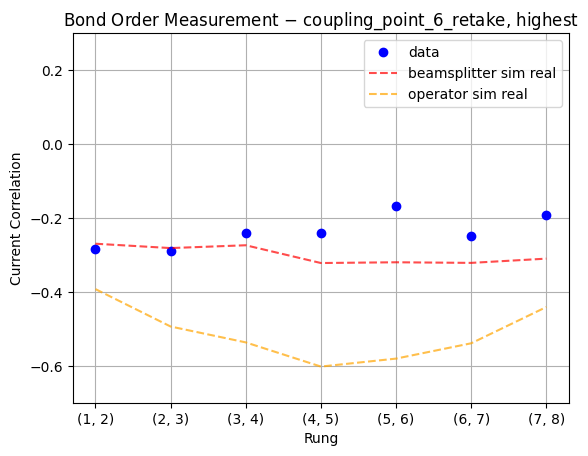

In [188]:
# plot
plt.plot(range(len(pairs)), bond_order_values_data, color='blue', marker='o', linestyle='', label='data')
plt.plot(range(len(pairs)), bond_order_values_BS, color='red', linestyle='--', alpha=0.7, label=f'beamsplitter sim {dephasing}')
plt.plot(range(len(pairs)), bond_order_values_operator, color='orange', linestyle='--', alpha=0.7, label=f'operator sim {dephasing}')

plt.xlabel('Rung')
plt.xticks(range(len(pairs)), [str(pair) for pair in pairs])


plt.ylabel('Current Correlation')

plt.legend()

plt.grid()

plt.title(f'Bond Order Measurement $-$ {coupling_point}, {eigenstate}')
# plt.title(f'Bond Order Measurement $-$ $0$-flux')

plt.ylim(-0.7,0.3)

plt.show()


plotting dephasing: real for coupling point: coupling_point_6_retake


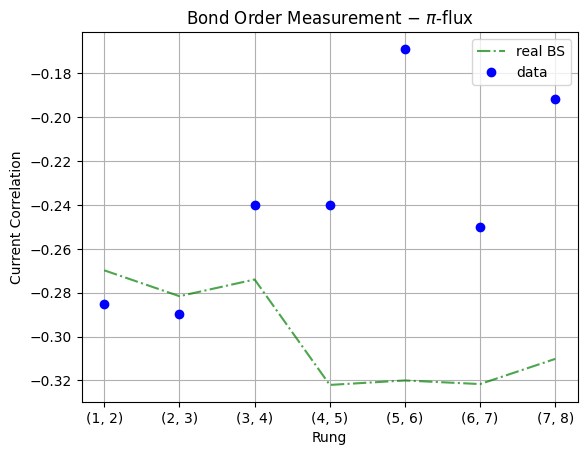

In [189]:
### sweep T2

max_T2 = 0
min_T2 = np.inf

for dephasing in data['simulation'][eigenstate_base]:
    try:
        dephasing = float(dephasing)
        if dephasing > max_T2:
            max_T2 = dephasing
        if dephasing < min_T2:
            min_T2 = dephasing
    except:
        pass

for dephasing in data['simulation'][eigenstate_base]:
    if coupling_point not in data['simulation'][eigenstate_base][dephasing]:
        continue

    print(f'plotting dephasing: {dephasing} for coupling point: {coupling_point}')
    bond_order_values_BS = [data['simulation'][eigenstate_base][dephasing][coupling_point_sim][str(pair)]['bond_order_value_BS'] for pair in pairs]
    bond_order_values_operator = [data['simulation'][eigenstate_base][dephasing][coupling_point_sim][str(pair)]['bond_order_value'] for pair in pairs]

    color_map = plt.cm.autumn

    linestyle = '--'
    coupling_point_index = coupling_point.split('_')[2]
    if dephasing == 'no_dephasing':
        if int(coupling_point_index) in [1,2,3]:
            sim_color = 'maroon'
        if int(coupling_point_index) in [4,5,6]:
            sim_color = 'gray'
    elif dephasing == 'no_dephasing_ramp':
        if int(coupling_point_index) in [1,2,3]:
            sim_color = 'darkred'
        if int(coupling_point_index) in [4,5,6]:
            sim_color = 'darkblue'
    elif dephasing == 'real':
        if int(coupling_point_index) in [1,2,3]:
            linestyle = '-.'
            sim_color = 'black'
        if int(coupling_point_index) in [4,5,6]:
            linestyle = '-.'
            sim_color = 'green'
    else:
        norm = mcolors.LogNorm(vmin=min_T2, vmax=max_T2)
        sim_color = color_map(norm(float(dephasing)))

    plt.plot(range(len(pairs)), bond_order_values_BS, color=sim_color, linestyle=linestyle, alpha=0.7, label=f'{dephasing} BS')


# plot
plt.plot(range(len(pairs)), bond_order_values_data, color='blue', marker='o', linestyle='', label='data')

plt.xlabel('Rung')
plt.xticks(range(len(pairs)), [str(pair) for pair in pairs])


plt.ylabel('Current Correlation')

plt.legend()

plt.grid()

plt.title(f'Bond Order Measurement $-$ $\\pi$-flux')
# plt.title(f'Bond Order Measurement $-$ $0$-flux')

# plt.ylim(-0.5, 0.5)

plt.show()


# 4. All Coupling Points

In [190]:
coupling_point_to_ratio = {
    'coupling_point_1': 1,
    'coupling_point_2': 2,
    'coupling_point_3': 3,
    'coupling_point_4': 1,
    'coupling_point_5': 2,
    'coupling_point_5_retake': 2,
    'coupling_point_6': 3,
    'coupling_point_6_retake': 3
}

In [191]:
all_coupling_points = [f'coupling_point_{i}' for i in range(1,7)]

dephasing = 'real'


### 4.1 Plot Bond Values

-1.674275404771594


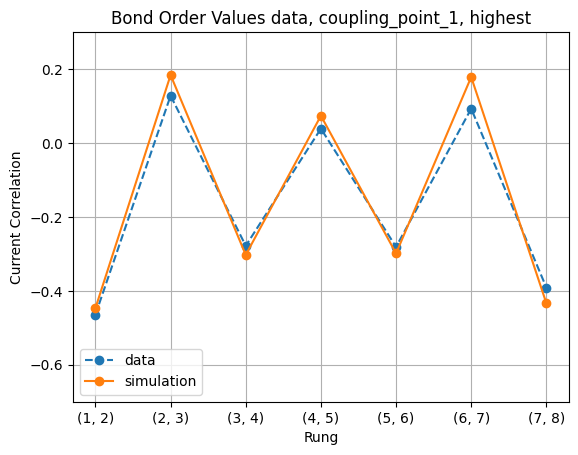

-0.3453050726737344


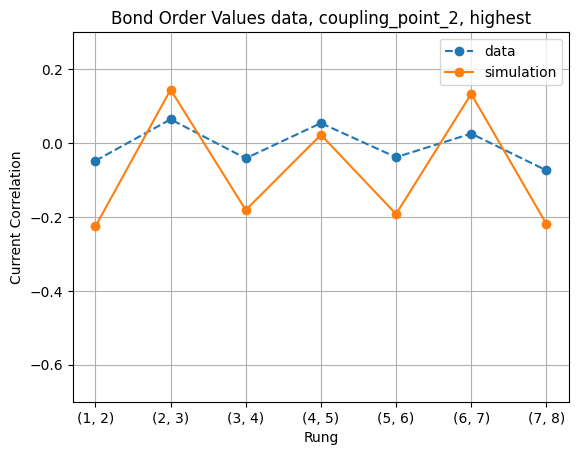

-0.304392260670268


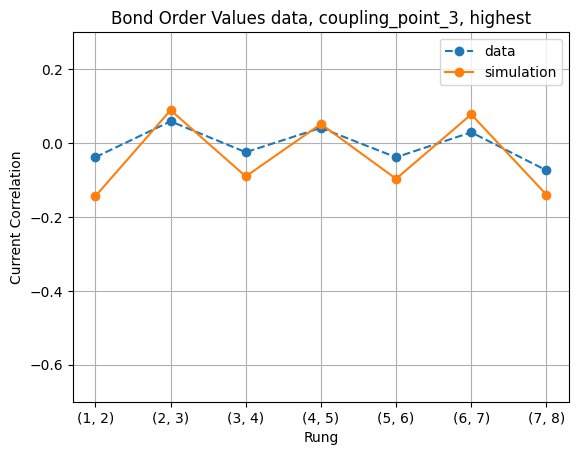

-0.8335903779723035


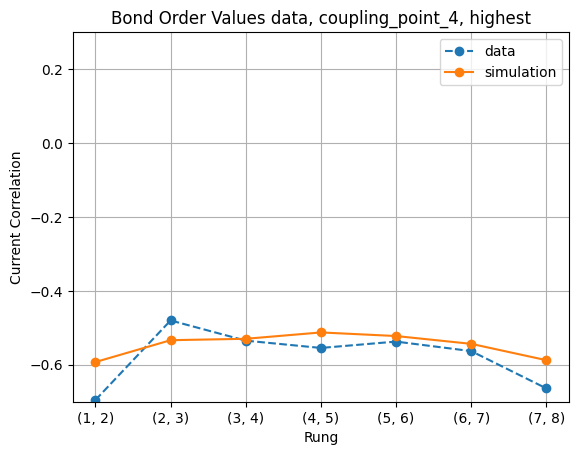

0.5435334534615658


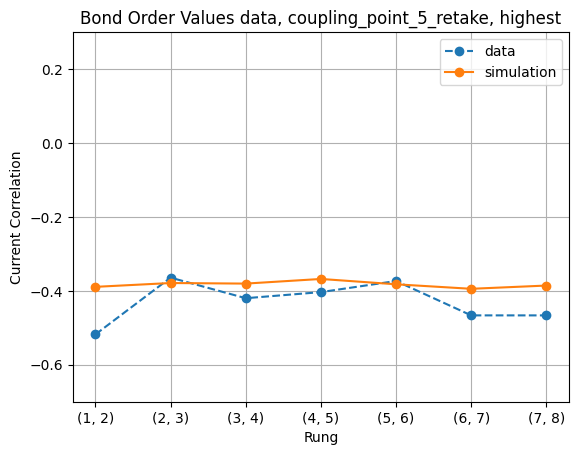

0.10571300276574816


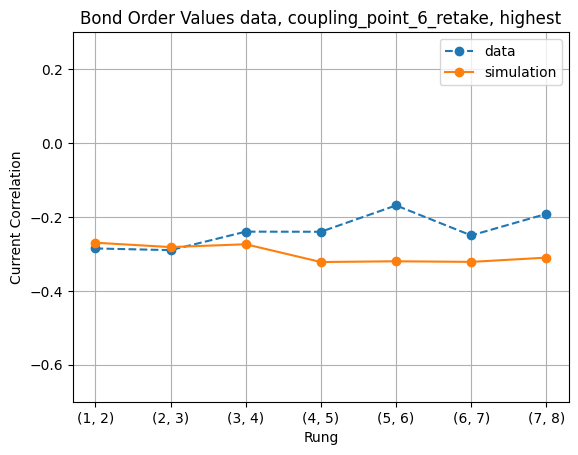

In [196]:
bond_order_parameters_0_flux = []
bond_order_parameters_error_0_flux = []
bond_order_parameters_0_flux_sim = []
ratios_0_flux = []

bond_order_parameters_pi_flux = []
bond_order_parameters_error_pi_flux = []
bond_order_parameters_pi_flux_sim = []
ratios_pi_flux = []

all_coupling_points = [
    'coupling_point_1',
    'coupling_point_2',
    'coupling_point_3',
    'coupling_point_4',
    'coupling_point_5_retake',
    'coupling_point_6_retake'
]

for coupling_point in all_coupling_points:
    coupling_point_index = coupling_point.split('_')[2]

    if not coupling_point in data['data'] and not coupling_point in data['simulation'][eigenstate][dephasing]:
        continue

    coupling_point_sim = None

    if coupling_point in data['data']:

        bond_order_values_data = [data['data'][coupling_point][eigenstate][str(pair)]['bond_order_value_corrected'] for pair in pairs]

        bond_order_value = data['data'][coupling_point][eigenstate]['bond_order_total_corrected']
        bond_order_error = data['data'][coupling_point][eigenstate]['bond_order_total_error_corrected']

        print(bond_order_value)
        if int(coupling_point_index) in [4,5,6]:
            ratios_0_flux.append(coupling_point_to_ratio[coupling_point])
            bond_order_parameters_0_flux.append(bond_order_value)
            bond_order_parameters_error_0_flux.append(bond_order_error)
        elif int(coupling_point_index) in [1,2,3]:
            ratios_pi_flux.append(coupling_point_to_ratio[coupling_point])
            bond_order_parameters_pi_flux.append(bond_order_value)
            bond_order_parameters_error_pi_flux.append(bond_order_error)


        # plot
        plt.plot(range(len(pairs)), bond_order_values_data, marker='o', linestyle='--', label='data')

    if coupling_point in data['simulation'][eigenstate_base][dephasing]:

        bond_order_values_BS = [data['simulation'][eigenstate_base][dephasing][coupling_point][str(pair)]['bond_order_value_BS'] for pair in pairs]
        
        bond_order_value_sim = data['simulation'][eigenstate_base][dephasing][coupling_point]['bond_order_total_BS']

        if int(coupling_point_index) in [4,5,6]:
            bond_order_parameters_0_flux_sim.append(bond_order_value_sim)
        elif int(coupling_point_index) in [1,2,3]:
            bond_order_parameters_pi_flux_sim.append(bond_order_value_sim)


        # plot
        plt.plot(range(len(pairs)), bond_order_values_BS, marker='o', label='simulation')


    plt.xlabel('Rung')
    plt.xticks(range(len(pairs)), [str(pair) for pair in pairs])


    plt.ylabel('Current Correlation')

    plt.grid()
    plt.legend()

    if int(coupling_point_index) in [4,5,6]:
        flux = '0 flux'
    else:
        flux = 'π flux'

    plt.title(f'Bond Order Values data, {coupling_point}, {eigenstate}')

    plt.ylim(-0.7, 0.3)

    plt.show()



In [193]:
bond_order_values_data = [data['data']['coupling_point_4'][eigenstate][str(pair)]['bond_order_value_corrected'] for pair in pairs]

ones = np.array([(-1)**i for i in range(len(bond_order_values_data))])
print(np.dot(bond_order_values_data, ones))

-0.8335903779723035


### 4.2 Plot Bond Order Parameters

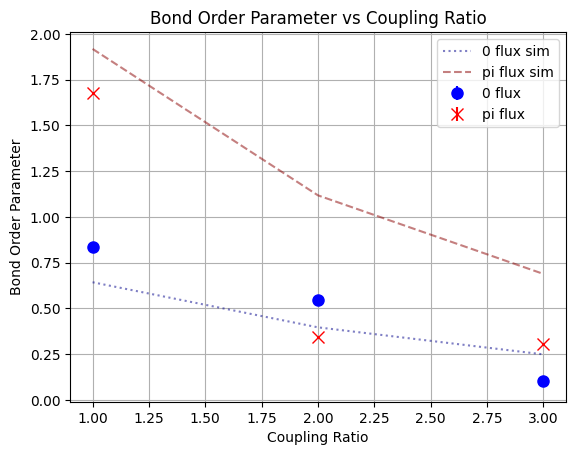

In [194]:
marker_size = 8
plt.errorbar(ratios_0_flux, np.abs(bond_order_parameters_0_flux), yerr=bond_order_parameters_error_0_flux, color='blue', marker='o', ms=marker_size, linestyle='', label='0 flux')
plt.errorbar(ratios_pi_flux, np.abs(bond_order_parameters_pi_flux), yerr=bond_order_parameters_error_pi_flux, color='red', marker='x', ms=marker_size, linestyle='', label='pi flux')


plt.plot(ratios_0_flux, np.abs(bond_order_parameters_0_flux_sim), color='darkblue', linestyle=':', alpha=0.5, label='0 flux sim')
plt.plot(ratios_pi_flux, np.abs(bond_order_parameters_pi_flux_sim), color='darkred', linestyle='--', alpha=0.5, label='pi flux sim')
plt.plot()

plt.xlabel('Coupling Ratio')
plt.ylabel('Bond Order Parameter')

# plt.ylim(0,3)

plt.title(f'Bond Order Parameter vs Coupling Ratio, {eigenstate}, {dephasing}')
plt.title(f'Bond Order Parameter vs Coupling Ratio')

plt.legend()
plt.grid()
plt.show()
